In [1]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd

from sklearn import datasets
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

random_state = 809

In [2]:
def plot_distribution_predictions(y_proba_pred, y_true, x_bins=20, labels=['Our Model'], **kargs):
    fig, ax = plt.subplots(figsize=(10, 8))
    if type(y_proba_pred)==pd.core.series.Series: y_proba_pred = [y_proba_pred]
    if type(labels)==str: labels = [labels]
        
    for i, proba in enumerate(y_proba_pred):
        sns.regplot(x=proba, y=y_true, x_bins=x_bins, fit_reg = False, 
                    label=labels[i], x_ci=None, ax=ax, **kargs)
    ax.set_ylabel('Fraction of Positives (Truth)', fontsize=14)
    ax.set_xlabel('Predicted Probability', fontsize=14)
    ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    ax.legend(loc='best')
    ax.set_title('Calibration Plot', fontsize=20)
    plt.show()

# Load a Dataset

In [3]:
X, y = datasets.make_classification(n_samples=100000, 
                                    n_features=20, n_informative=2, n_redundant=10, 
                                    random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
X_train

array([[ 0.26157824, -1.27499392, -0.61904112, ..., -0.87566601,
         0.12758843, -0.7286879 ],
       [ 0.27263211,  0.66397324,  0.89478059, ...,  0.87583963,
         0.60661642, -0.07643253],
       [-0.59636151,  0.80231861,  0.05793377, ...,  2.0686794 ,
        -0.27174117, -0.5592253 ],
       ...,
       [-0.34519819,  0.85867806,  0.86476754, ...,  1.39042793,
        -0.10618618, -0.02255792],
       [-0.35557848,  0.90186746, -0.99458378, ...,  1.66764792,
        -0.0470378 , -0.39705885],
       [-0.06277863,  0.57533863, -0.05373836, ...,  2.01922453,
         0.44845864,  0.24539408]])

# 1- Logistic Regression Example

In [4]:
lr = LogisticRegression(penalty='none')
lr.fit(X_train, y_train)

# We can either Predict a class with a default threshold of 0.5
y_pred = lr.predict(X_test)
df_predictions = pd.DataFrame(y_pred, columns=['Predicted Class (default threshold)'])

# Or we can have probabilities
prob_pos = lr.predict_proba(X_test)[:, 1]
df_predictions['Predicted Probability'] = prob_pos

# We will also compare to the truth
df_predictions['Truth'] = y_test
df_predictions

,Predicted Class (default threshold),Predicted Probability,Truth
0,1,0.999861,1
1,0,0.156596,0
2,1,1.000000,1
3,1,0.999173,1
4,1,0.948003,1
...,...,...,...
29995,0,0.219318,0
29996,1,0.815402,1
29997,0,0.345278,1
29998,1,0.628255,0


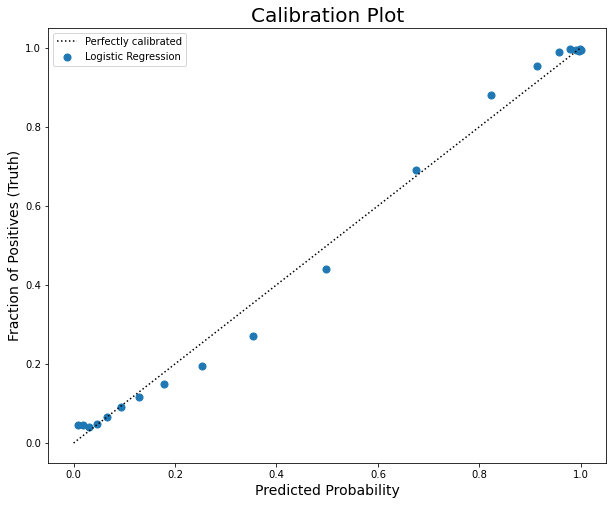

In [5]:
plot_distribution_predictions(df_predictions['Predicted Probability'], df_predictions['Truth'], 
                              labels='Logistic Regression')

The Logistic Regression does a pretty good job here. 

If, for example, it predictcs a probability of around 70% of being of class 1, about 70% of such observations have class 1.

This is not always the case.

# 2- Support Vector Classifier Example

In [6]:
svc = LinearSVC(max_iter=10000)
svc.fit(X_train, y_train)

# We can either predict a class
y_pred_svc = svc.predict(X_test)
df_pred_svc = pd.DataFrame(y_pred_svc, columns=['Predicted Class'])

# The SVC (or SVM for that matter) does not give probabilities, 
# Only gives the distance from the boundary, which separates the hyper-plane of SVC 
# We look at the decision function and do a MinMax rescale to get pseudo probabilities
prob_pos_svc = lr.decision_function(X_test)
prob_pos_svc = (prob_pos_svc - prob_pos_svc.min()) / (prob_pos_svc.max() - prob_pos_svc.min())
df_pred_svc['Predicted Probability'] = prob_pos_svc
df_pred_svc['Decision Function'] = svc.decision_function(X_test)

# We will also compare to the truth
df_pred_svc['Truth'] = y_test
df_pred_svc

,Predicted Class,Predicted Probability,Decision Function,Truth
0,1,0.710878,2.722271,1
1,0,0.324974,-0.544325,0
2,1,0.917579,4.473113,1
3,1,0.645718,2.171973,1
4,1,0.492526,0.870507,1
...,...,...,...,...
29995,0,0.340102,-0.413971,0
29996,1,0.440741,0.432588,1
29997,0,0.363106,-0.222780,1
29998,1,0.405647,0.141011,0


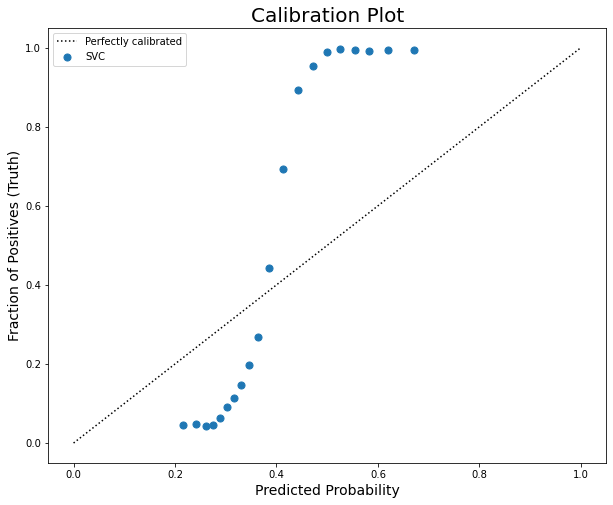

In [7]:
plot_distribution_predictions(df_pred_svc['Predicted Probability'], 
                              df_pred_svc['Truth'], labels='SVC')

Here, the SVC is much worse than the logistic regression:

Observations that have a predicted probability of around 20% (bottom left of the distribution) are very rarely of class 1. 
When we should expect about 20% of those observations to be of class 1. The predicted probability should be much lower. This is what we fix through calibration

# 3- Calibration of the SVC: Isotonic Regression 

We fit:
$$p(y_i=1|f_i) = m(f_i)$$

Where:
- $y_i$ is the true label
- $f_i$ is the output from the SVC (the decision function, not the pseudo probability we created)
- $m$ is a monotonically increasing function to be determined


If we want to use Platt Scaling, we want to estimate via maximum likelyhood A and B such that:
$$p(y_i=1|f_i) = \frac{1}{1+exp(A f_i+B)}$$


In [8]:
# We fit an Isotonic Regression
calibration_reg = IsotonicRegression()
calibration_reg.fit(df_pred_svc['Decision Function'].values.reshape(-1, 1), y_test)
df_pred_svc['Calibrated Probability'] = calibration_reg.predict(df_pred_svc['Decision Function'].values.reshape(-1, 1))


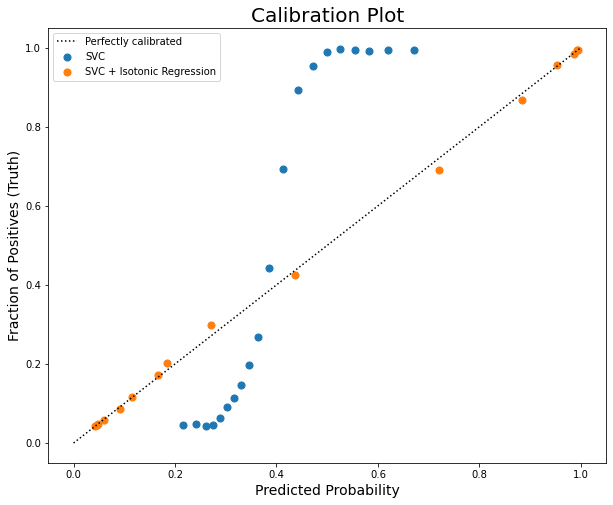

In [9]:
plot_distribution_predictions([df_pred_svc['Predicted Probability'], df_pred_svc['Calibrated Probability']], 
                              df_pred_svc['Truth'], labels=['SVC', 'SVC + Isotonic Regression'])

## 3a- What changed ?

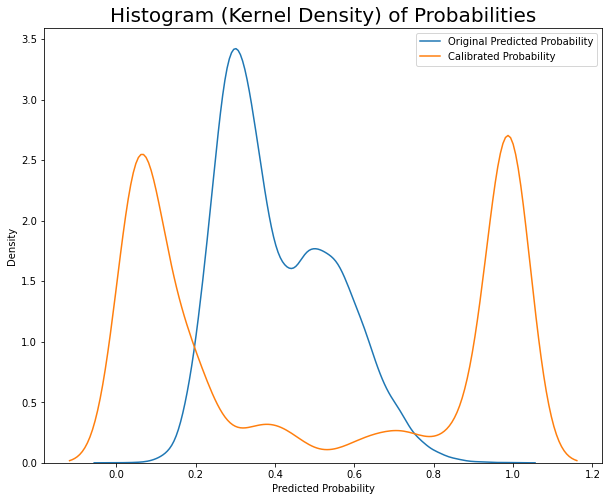

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.kdeplot(df_pred_svc['Predicted Probability'], ax=ax, label='Original Predicted Probability')
sns.kdeplot(df_pred_svc['Calibrated Probability'], ax=ax, label='Calibrated Probability')
ax.set_title('Histogram (Kernel Density) of Probabilities', fontsize=20)
ax.legend(loc='best')
plt.show()

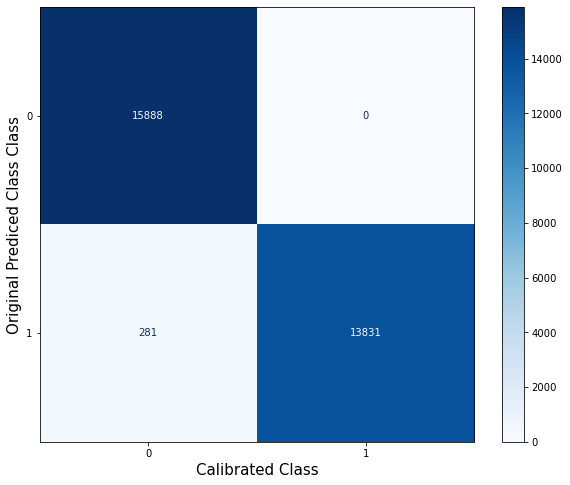

In [11]:
threshold = 0.5
df_pred_svc['Calibrated Class'] = (df_pred_svc['Calibrated Probability']>threshold)*1

fig, ax= plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(df_pred_svc['Predicted Class'], 
                                        df_pred_svc['Calibrated Class'], ax=ax, normalize=None, cmap='Blues')
ax.set_xlabel('Calibrated Class', fontsize=15)
ax.set_ylabel('Original Prediced Class Class', fontsize=15)
plt.show()

## 3c- Problem: This is all done in Sample

We picked $m$ using data from the TEST set but we also plot the TEST set above

Ideally, we would want to have another test set to plot the results. 

But if we are going to do that, we might as well use folds and do it in the training set to begin with!

In [12]:
svc_2 = LinearSVC(max_iter=10000)
calibrated_classifier = CalibratedClassifierCV(svc_2, cv=5, method='isotonic')
calibrated_classifier.fit(X_train, y_train)

CalibratedClassifierCV(base_estimator=LinearSVC(max_iter=10000), cv=5,
                       method='isotonic')

In [13]:
df_pred_svc['Cross Validation Probability'] = calibrated_classifier.predict_proba(X_test)[:, 1]
df_pred_svc['Cross Validation Class'] = calibrated_classifier.predict(X_test)

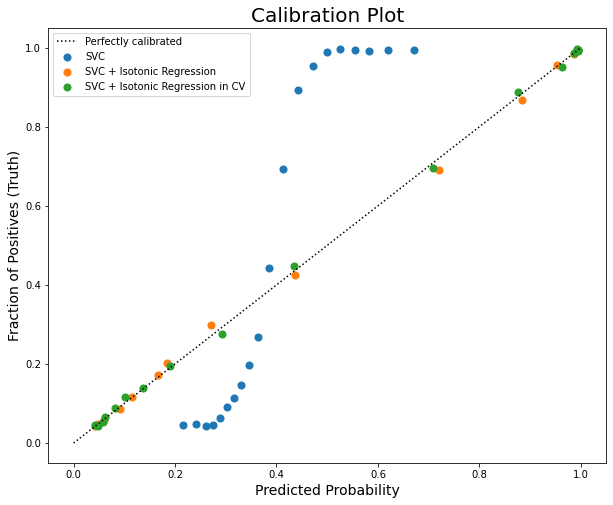

In [14]:
plot_distribution_predictions([df_pred_svc['Predicted Probability'], 
                               df_pred_svc['Calibrated Probability'], 
                              df_pred_svc['Cross Validation Probability']], 
                              df_pred_svc['Truth'], labels=['SVC', 'SVC + Isotonic Regression', 'SVC + Isotonic Regression in CV'])

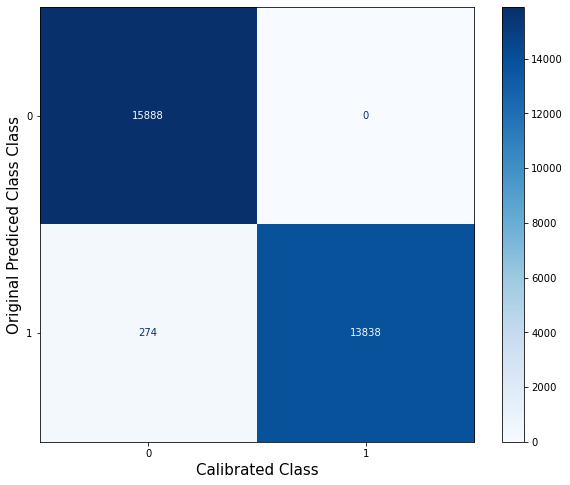

In [15]:
fig, ax= plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(df_pred_svc['Predicted Class'], 
                                        df_pred_svc['Cross Validation Class'], ax=ax, normalize=None, cmap='Blues')
ax.set_xlabel('Calibrated Class', fontsize=15)
ax.set_ylabel('Original Prediced Class Class', fontsize=15)
plt.show()

## 3d- Showing CalibratedClassifierCV is the same as running the calibration ourselves
If we have already fitted the SVC:

We can 'prefit' as an argument in CalibratedClassifierCV rather than the  number of folds

It means the SVC will not be re-trained and the provided data is only used for calibration

In [16]:
calibrated_classifier = CalibratedClassifierCV(svc, cv='prefit', method='isotonic')
calibrated_classifier.fit(X_test, y_test)

CalibratedClassifierCV(base_estimator=LinearSVC(max_iter=10000), cv='prefit',
                       method='isotonic')

In [17]:
df_pred_svc['Cross Validation Probability CalibratedClassifierCV'] = calibrated_classifier.predict_proba(X_test)[:, 1]

In [18]:
df_pred_svc[['Calibrated Probability', 'Cross Validation Probability CalibratedClassifierCV']]

,Calibrated Probability,Cross Validation Probability CalibratedClassifierCV
0,0.997187,0.997187
1,0.116099,0.116099
2,1.000000,1.000000
3,0.994781,0.994781
4,0.985994,0.985994
...,...,...
29995,0.174881,0.174881
29996,0.884211,0.884211
29997,0.209790,0.209790
29998,0.642473,0.642473
